In [1]:
from DatabankLib.protein_functions import *
import yaml

#databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"


# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()

/home/sosamuli/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations


In [8]:
# --- First pass: organize systems into a structure {replica: {forcefield: system}} ---
grid = {}

#protein_system = 'KRS1-72_salt'
protein_system = 'ChiZ_salt'

for system in systems:
    if protein_system not in system['SYSTEM']:
        continue

    trj = system['TRJ'][0][0]

    # Example: KRS1-72_replica_05_AMBER03WS_2000ns.xtc
    match = re.search(r"replica_(\d+)_([A-Za-z0-9\-]+)_", trj)
    #match = re.search(r"replica_(\d+)_([A-Za-z0-9]+)_", trj)
    if not match:
        print("Could not parse:", trj)
        continue

    replica = match.group(1)
    forcefield = match.group(2)

    if replica not in grid:
        grid[replica] = {}
    grid[replica][forcefield] = system


# --- Determine sorted order of replicas and forcefields ---
replicas = sorted(grid.keys(), key=lambda x: int(x))

print(replicas)

desired_order = [
    "AMBER03WS",
    "AMBER99SB-DISP",
    "AMBER99SBWS",
    "DESAMBER",
    "CHARMM36M",
]

forcefields = sorted(
    {ff for rep in grid.values() for ff in rep.keys()},
    key=lambda ff: desired_order.index(ff)
)
print(forcefields)

#forcefields = sorted(
#    {ff for rep in grid.values() for ff in rep.keys()}
#)
#print(forcefields)

n_rows = len(replicas)
n_cols = len(forcefields)# * 2   # because each system has 2 images (chem + relax)

#fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))


['01', '02', '03', '04', '05']
['AMBER03WS', 'AMBER99SB-DISP', 'AMBER99SBWS', 'DESAMBER', 'CHARMM36M']


In [9]:
def plot_quality_heatmap(data_dict, ax, vmax=None,
                         show_residue_labels=True, show_nucleus_labels=True):
    """
    Plot a heatmap onto a provided axis `ax`.
    No colorbar is created here; caller handles shared colorbar.
    """

    # --- Prepare data ---
    df = pd.DataFrame(data_dict).T

    # Extract "Averages" and sort
    if "Averages" in df.index:
        averages = df.loc["Averages"]
        df = df.drop("Averages")
    else:
        averages = None

    # Sort residues numerically
    def residue_sort_key(name):
        m = re.match(r"(\d+)", str(name))
        return int(m.group(1)) if m else float("inf")

    df = df.loc[sorted(df.index, key=residue_sort_key)]

    # Add Averages row back at bottom
    if averages is not None:
        df.loc["Averages"] = averages

    # Transpose for plotting
    df_t = df.T

    # --- Plot heatmap (NO colorbar!) ---
    sns.heatmap(
        df_t,
        cmap="RdYlGn_r",
        vmax=vmax,
        linewidths=0.5,
        cbar=False,
        ax=ax
    )

    # --- Axis labels ---
    if show_residue_labels:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    else:
        ax.set_xticklabels([])
        ax.set_xlabel("")

    if show_nucleus_labels:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    ax.set_title("")


In [10]:
import matplotlib.gridspec as gridspec

def plot_heatmap_grid(type_name, yaml_filename, vmax=None,
                      colorbar_width=0.05, colorbar_pad=0.02,
                      figsize_per_cell=(4, 4)):
    """
    Build a grid of heatmaps from per-system YAMLs (one YAML per simulation folder).
    Places a shared, non-overlapping colorbar in a dedicated GridSpec column.
    - yaml_filename: name of YAML file inside each system folder (e.g. "spin_relaxation_quality.yaml")
    - vmax: color scale upper limit (passed to plot_quality_heatmap)
    - colorbar_width: fraction of figure width allocated to colorbar column
    - colorbar_pad: gap between heatmaps and colorbar (as fraction of figure width)
    - figsize_per_cell: (width,height) of each heatmap cell in inches
    """

    # Number of rows/cols come from your grid (replicas, forcefields)
    n_rows = len(replicas)
    n_cols = len(forcefields)

    #print(replicas)
    
    # Build figure width/height
    fig_w = figsize_per_cell[0] * n_cols + figsize_per_cell[0] * colorbar_width *  (1/figsize_per_cell[0])
    fig_h = figsize_per_cell[1] * n_rows
    # A simpler, reliable figsize:
    fig = plt.figure(figsize=(4 * n_cols + 1.0, 4 * n_rows))

    # GridSpec: data grid (n_rows x n_cols) + 1 column for colorbar
    gs = gridspec.GridSpec(
        n_rows,
        n_cols + 1,
        width_ratios=[1] * n_cols + [colorbar_width],
        wspace=0.05,
        hspace=0.05
    )

    # Create axes matrix for the heatmaps
    axes = [[fig.add_subplot(gs[r, c]) for c in range(n_cols)] for r in range(n_rows)]

    first_mappable = None  # will hold an artist for colorbar

    for r_idx, replica in enumerate(replicas):
        for c_idx, forcefield in enumerate(forcefields):
            ax = axes[r_idx][c_idx]

            # If no system for this cell, turn axis off
            if forcefield not in grid[replica]:
                ax.axis("off")
                continue

            system = grid[replica][forcefield]
            dataFolder = os.path.join('../../Data/Simulations', system['path'])
            yaml_path = os.path.join(dataFolder, yaml_filename)

            print(yaml_path)
            if not os.path.exists(yaml_path):
                ax.axis("off")
                continue

            # Load YAML dict
            with open(yaml_path, "r") as f:
                data_dict = yaml.safe_load(f)

            # Which outer labels to show
            show_x = (r_idx == n_rows - 1)   # residues only on bottom row
            show_y = (c_idx == 0)           # nucleus labels only on left column

            # Draw the heatmap onto the provided axis (plot_quality_heatmap should use cbar=False)
            #print("DATA:", data)
            plot_quality_heatmap(
                data_dict=data_dict,
                ax=ax,
                vmax=vmax,
                show_residue_labels=show_x,
                show_nucleus_labels=show_y
            )

            # seaborn heatmap creates QuadMesh in ax.collections (index 0)
            # Save first mappable for colorbar
            if first_mappable is None:
                # prefer QuadMesh (image) or collection
                if len(ax.collections) > 0:
                    first_mappable = ax.collections[0]
                else:
                    # fallback: try the last image
                    imgs = ax.get_images()
                    if len(imgs) > 0:
                        first_mappable = imgs[-1]

            # Column titles on first row
            if r_idx == 0:
                ax.set_title(forcefield, fontsize=13)

            # Row label on leftmost column
            if c_idx == 0:
                ax.set_ylabel(f"Replica {replica}", fontsize=13)

    # If we found no mappable (nothing plotted), just return the figure
    if first_mappable is None:
        fig.suptitle(type_name, fontsize=18)
        fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.05)
        plt.show()
        return fig

    # --------------------------
    # Add a dedicated colorbar axis (entire last column)
    # --------------------------
    cax = fig.add_subplot(gs[:, -1])  # span all rows in the last column
    # Draw the colorbar vertically in that axis
    cb = fig.colorbar(first_mappable, cax=cax, orientation="vertical")
    # Optionally tweak colorbar label size/ticks here:
    cb.ax.tick_params(labelsize=10)

    # --------------------------
    # Final layout adjustments (do NOT use tight_layout)
    # --------------------------
    fig.suptitle(type_name, fontsize=18)

    # Manually adjust margins so the colorbar column won't be overlapped
    fig.subplots_adjust(
        left=0.03,    # space left edge
        right=0.97,   # right edge (colorbar fits in gs last column)
        top=0.92,
        bottom=0.05
    )

    plt.show()
    return fig


../../Data/Simulations/8b7/b2b/8b7b2b7e5d50f8c635ce161417896a2c9ce9abcb/63e0ad2372049417a24dbcb3102ef1fef5344ca2/chemical_shift_quality.yaml
../../Data/Simulations/56f/b4a/56fb4a58dd1fd02c0c8651f6b1502cbef8de70a2/98cb10b22eb76b92238ac15a8c217e63464a7d1c/chemical_shift_quality.yaml
../../Data/Simulations/6b1/62b/6b162bf7bd24f5cdb8a9254dc87f3f2ef36f1753/fe72ba456500bac9453383d7930935efc2cfb859/chemical_shift_quality.yaml
../../Data/Simulations/519/2dd/5192dd299cfae2499dc50b32e00293a0226b2a9b/f4506545a6c8d7629c6a09da6d06319761a3afcc/chemical_shift_quality.yaml
../../Data/Simulations/e7d/d1b/e7dd1b6f6ebbe28b5d78f21902a36668b5415ddb/8513597aca9cf1b4e5afb4eb0a9b2eb6a7e1839f/chemical_shift_quality.yaml
../../Data/Simulations/f94/f3b/f94f3b4bb2a04e97e8973c1b824053b91c5890c7/99b1d9ff07c519b33710f1e4d2dec4a59082324b/chemical_shift_quality.yaml
../../Data/Simulations/f27/30d/f2730dcd274f4b31cab34cf9c7f7fbfd3fbbcd54/8c8ce7913551266310fd934f6f40a50381f14111/chemical_shift_quality.yaml
../../Data/Si

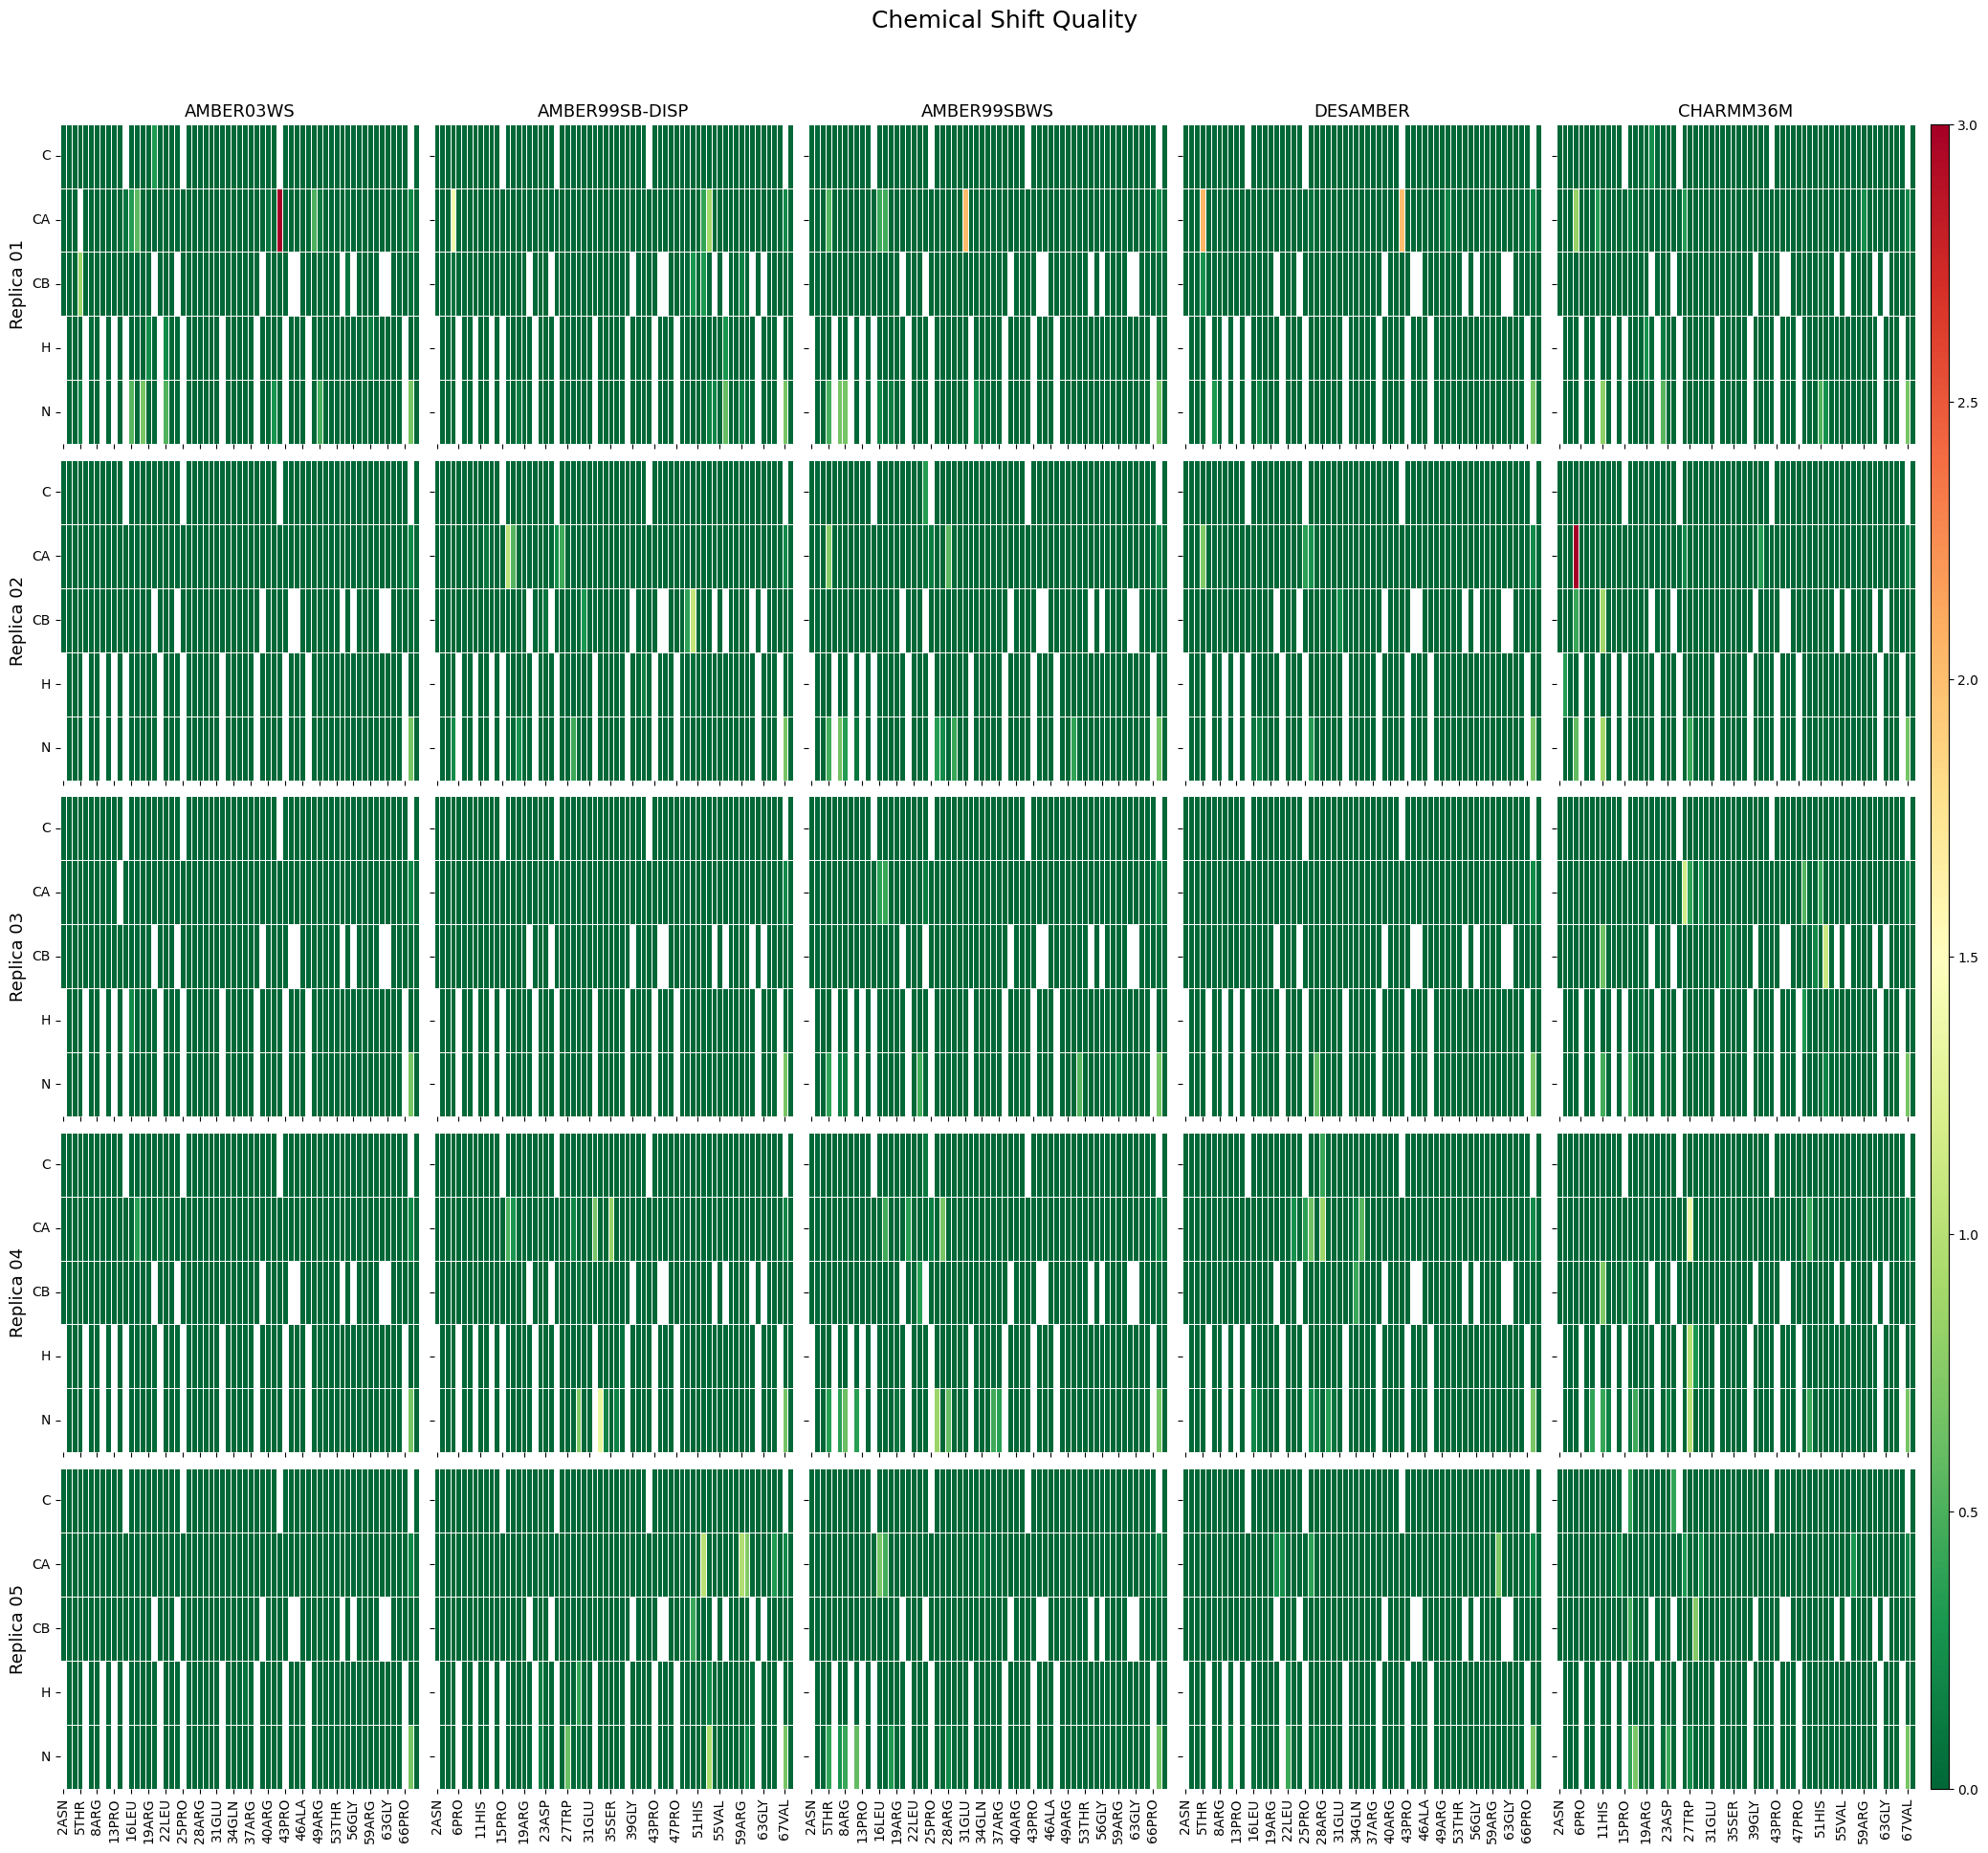

../../Data/Simulations/8b7/b2b/8b7b2b7e5d50f8c635ce161417896a2c9ce9abcb/63e0ad2372049417a24dbcb3102ef1fef5344ca2/spin_relaxation_quality.yaml
../../Data/Simulations/56f/b4a/56fb4a58dd1fd02c0c8651f6b1502cbef8de70a2/98cb10b22eb76b92238ac15a8c217e63464a7d1c/spin_relaxation_quality.yaml
../../Data/Simulations/6b1/62b/6b162bf7bd24f5cdb8a9254dc87f3f2ef36f1753/fe72ba456500bac9453383d7930935efc2cfb859/spin_relaxation_quality.yaml
../../Data/Simulations/519/2dd/5192dd299cfae2499dc50b32e00293a0226b2a9b/f4506545a6c8d7629c6a09da6d06319761a3afcc/spin_relaxation_quality.yaml
../../Data/Simulations/e7d/d1b/e7dd1b6f6ebbe28b5d78f21902a36668b5415ddb/8513597aca9cf1b4e5afb4eb0a9b2eb6a7e1839f/spin_relaxation_quality.yaml
../../Data/Simulations/f94/f3b/f94f3b4bb2a04e97e8973c1b824053b91c5890c7/99b1d9ff07c519b33710f1e4d2dec4a59082324b/spin_relaxation_quality.yaml
../../Data/Simulations/f27/30d/f2730dcd274f4b31cab34cf9c7f7fbfd3fbbcd54/8c8ce7913551266310fd934f6f40a50381f14111/spin_relaxation_quality.yaml
../../

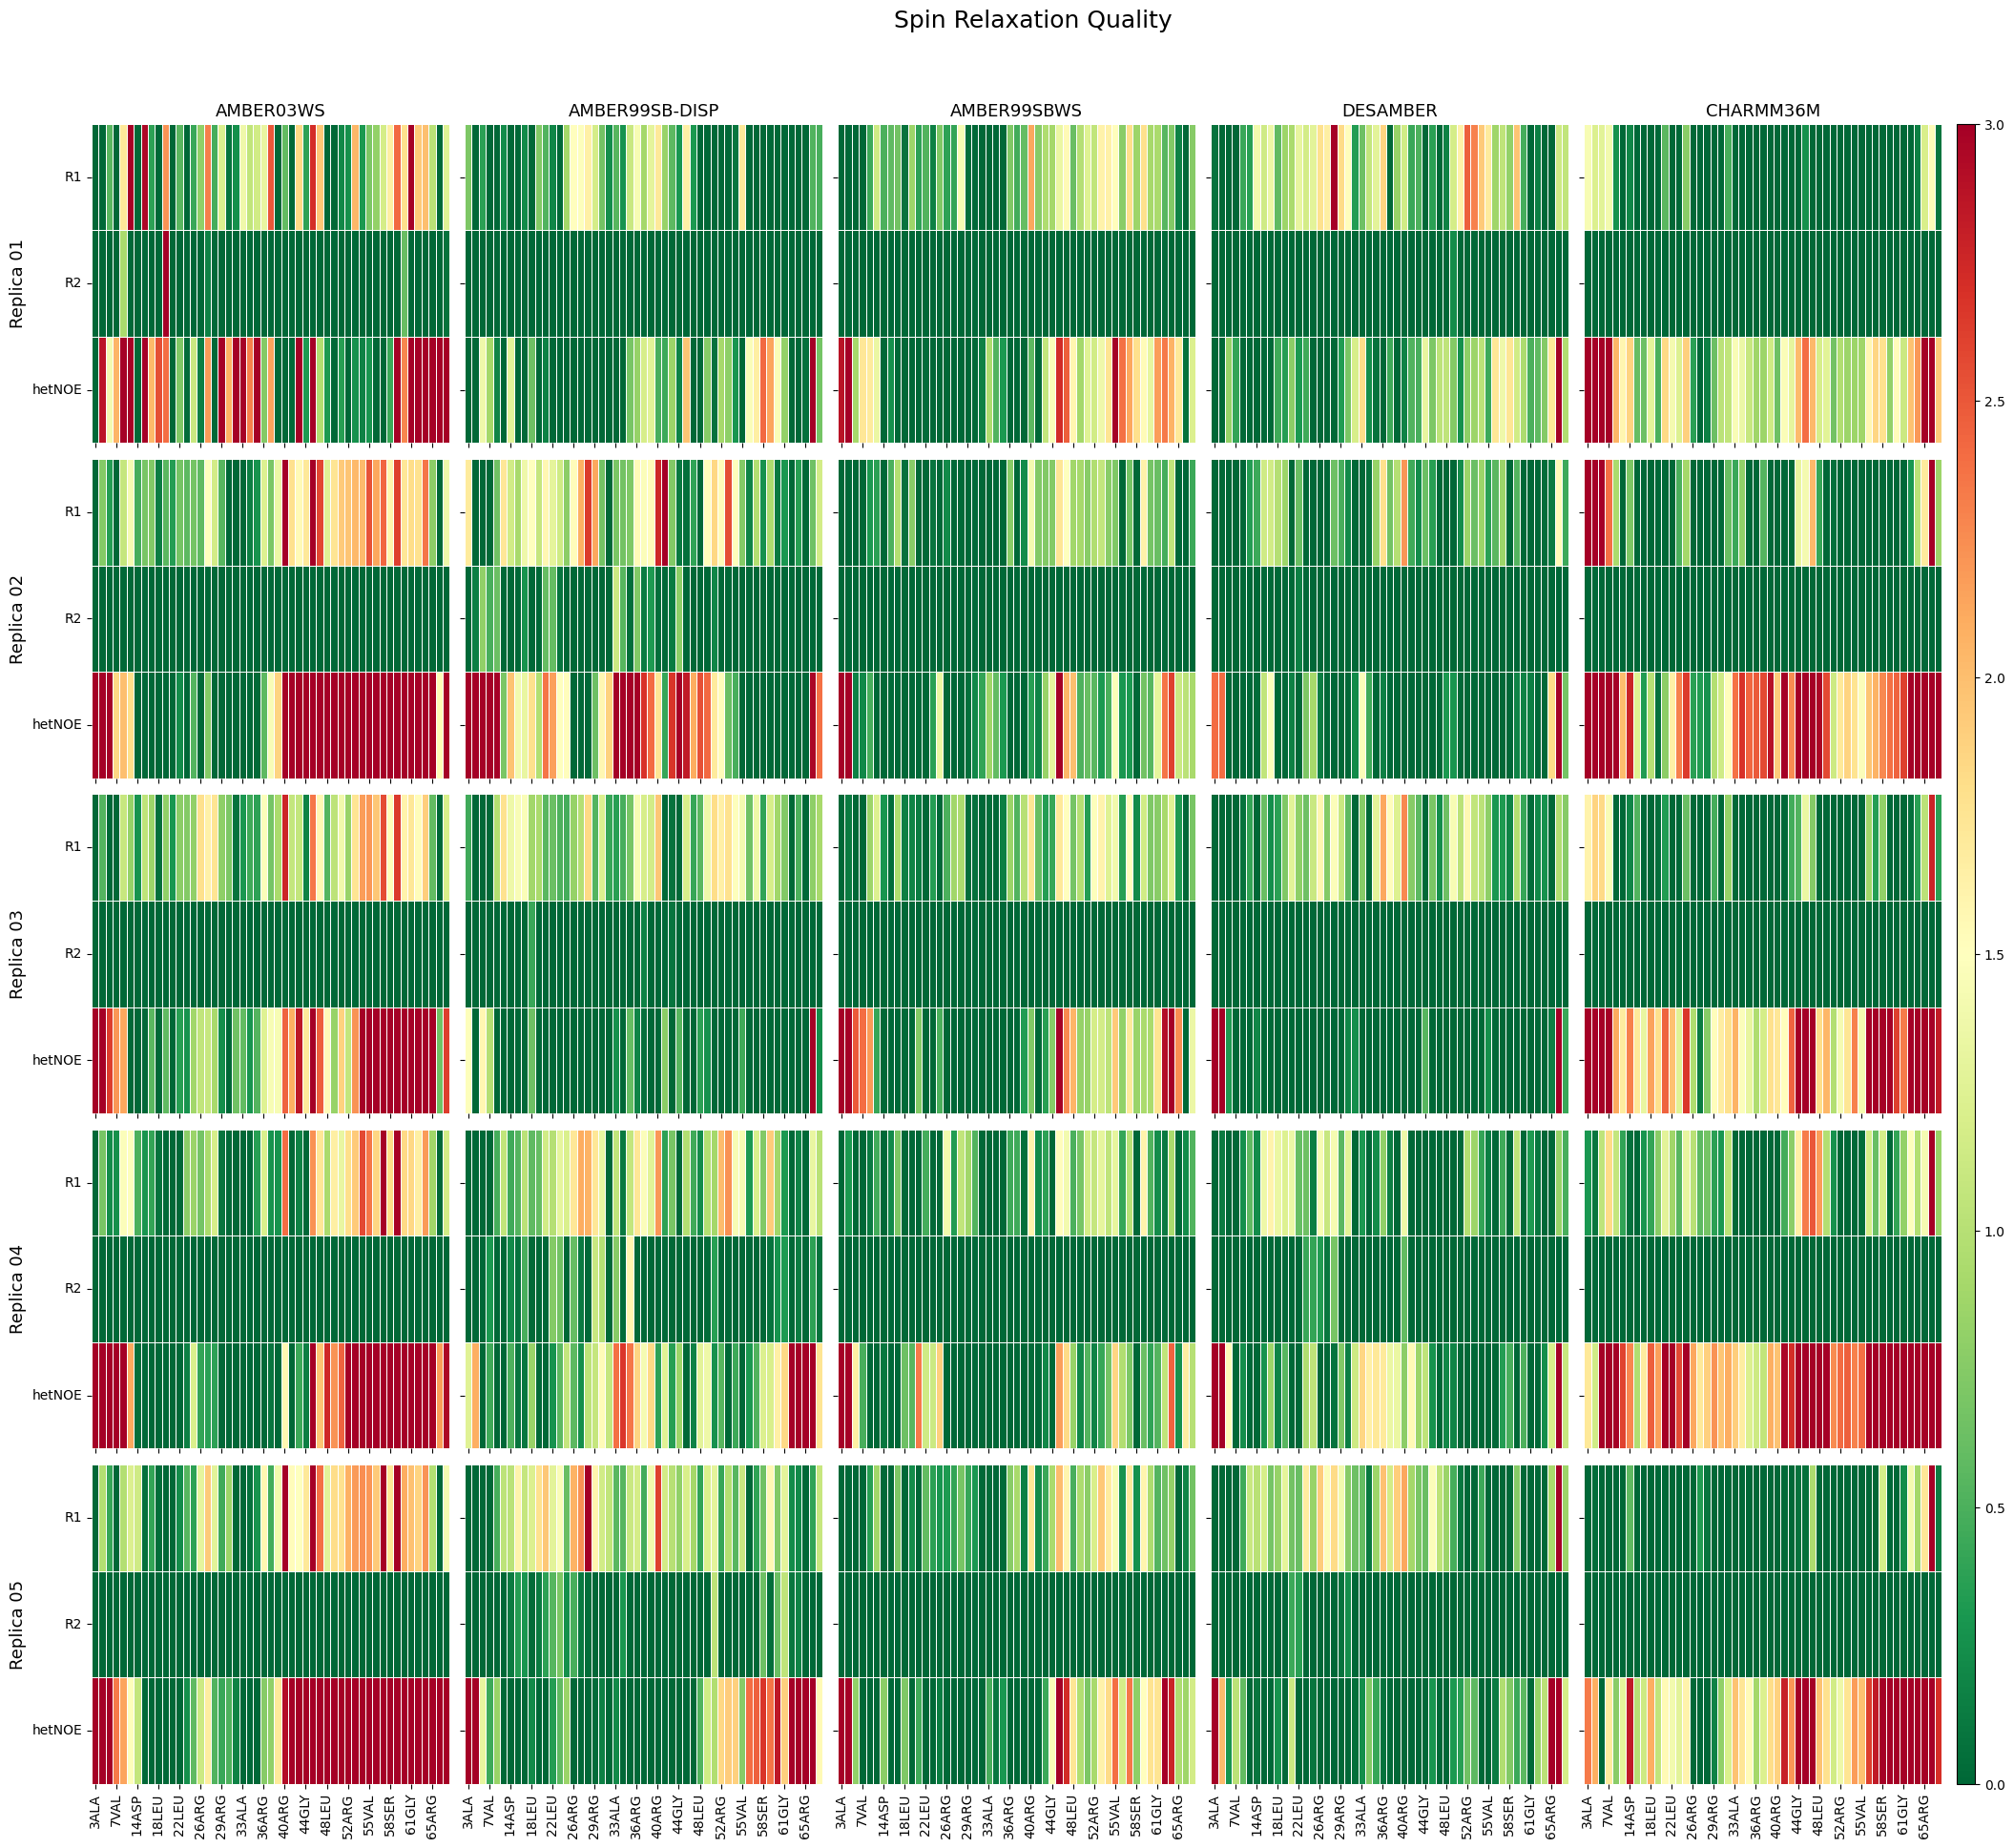

In [11]:
# Chemical shifts (YAML assumed!)
fig = plot_heatmap_grid(
    type_name="Chemical Shift Quality",
    yaml_filename="chemical_shift_quality.yaml",
    vmax=3
)

fig.savefig(protein_system + "_chemical_shift_quality.pdf", dpi=300, bbox_inches="tight")

# Relaxation heatmaps
fig = plot_heatmap_grid(
    type_name="Spin Relaxation Quality",
    yaml_filename="spin_relaxation_quality.yaml",
    vmax=3
)

fig.savefig(protein_system + "_spin_relaxation_quality.pdf", dpi=300, bbox_inches="tight")


In [21]:
for system in systems:
    print(system)

System(119): d02/dcf/d02dcfaaecf4ca9eadb12bfa047b8f0388c744c6/0db7a9f05c27cbc152110cbd562bec2d201ccf06/
System(26): 591/0c7/5910c7a9f3a841dfafd047dc3b509a00c214f140/0b83ddddf9f2e8ecac81dcaa7fef667472d28184/
System(96): c8a/f55/c8af5520531bad6d0040961170e6a8ba1fe76014/bf38f916a33d4af177646ebdd257f293fb04aa0c/
System(130): a47/416/a47416e44ba9ebece8aa9136736d7b43611cc554/361fa94d8e81de8ac1e30e9db306cb1148ec7c44/
System(49): bf3/0ed/bf30ed6d666efbcbf25af9c75ea0b820f1584bf6/f68e66dbd16cbc101bbfa34d3f9a1613166434a4/
System(79): a02/63c/a0263cccccb94ac769a50f128dd566f27a12216f/e6f23f69d25f4bb156c8051587567f1c85a8648a/
System(13): 177/415/1774152d093244b14fe1aed51284089c812174cd/d47413ba289f58dcd92b3ac753e222dd910bd04e/
System(135): 95a/41b/95a41b30aa70b50a1a193031f46c2832e94d4b40/1ede1e35b6a3e3c7b9de1f34c18b5b253cef7fdc/
System(172): f27/30d/f2730dcd274f4b31cab34cf9c7f7fbfd3fbbcd54/8c8ce7913551266310fd934f6f40a50381f14111/
System(87): f27/981/f27981c4bde82a195ed77bed88eb0cc45699e96f/5b0d5aea